# StarDist Training Test Notebook

This notebook demonstrates the StarDist training workflow using the **nuclei** test project:

1. **Setup** — point to the nuclei project (labels already exist)
2. **Generate patches from labels** — augment saved label crops into training patches
3. **Train** — train a StarDist2D model on the patches
4. **Predict** — run the trained model on a test image
5. **Visualise** — compare input, ground truth, and prediction

## 1. Import Libraries

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile

from napari_ai_lab.Augmenters.simple_augmenter import SimpleAugmenter
from napari_ai_lab.models.image_data_model import ImageDataModel
from napari_ai_lab.Segmenters.GlobalSegmenters.StardistSegmenter import (
    StardistSegmenter,
)

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
2026-04-01 19:21:59.712591: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 19:21:59.745062: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-01 19:21:59.745092: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-01 19:21:59.745097: E

## 2. Setup Project

The nuclei project already has saved label crops in `labels/input0` and `labels/truth0`.

In [2]:
project_path = Path("/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/")

image_data_model = ImageDataModel(str(project_path))

print(f"Project: {project_path}")
print(f"Images found: {image_data_model.get_image_count()}")
print(f"Labels dir: {image_data_model.get_labels_directory()}")
print(f"Label crops (input0): {list(image_data_model.get_labels_directory().glob('input0/*.tif'))}")

Project: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei
Images found: 200
Labels dir: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/labels
Label crops (input0): [PosixPath('/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/labels/input0/IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif'), PosixPath('/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/labels/input0/IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00001.tif'), PosixPath('/home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/labels/input0/IXMtest_A12_s7_w1EAEEA614-51ED-43B3-A4FF-088730911E4C_00000.tif')]


## 3. Delete Old Patches and Generate New Patches from Labels

We use the `from_label_boxes` workflow: the augmenter reads label crops from disk and generates augmented training patches.

In [3]:
# Delete old patches
image_data_model.delete_patches(axis="yx")

# Create augmenter and configure patch generation
augmenter = SimpleAugmenter()
image_data_model.set_augmenter(augmenter)
image_data_model.set_patch_size((256, 256))
image_data_model.set_num_patches(200)

# Generate patches from the saved label crops
patches_dir = image_data_model.generate_patches_from_labels(axis="yx", axes_string="YX")

print(f"\nPatches directory: {patches_dir}")
print(f"Input patches: {len(list(Path(patches_dir, 'input0').glob('*.tif')))}")
print(f"Truth patches: {len(list(Path(patches_dir, 'ground_truth0').glob('*.tif')))}")

🎨 Generating 200 patches × 3 label crop(s) = 600 total...
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (10/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (20/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (30/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (40/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (50/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (60/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (70/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (80/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB_00000.tif (90/600)
  Generating patches for IXMtest_A02_s1_w1051DAA7C-7042-435F

## 4. Visualise a Few Patches

Quick sanity check — display some input/truth patch pairs.

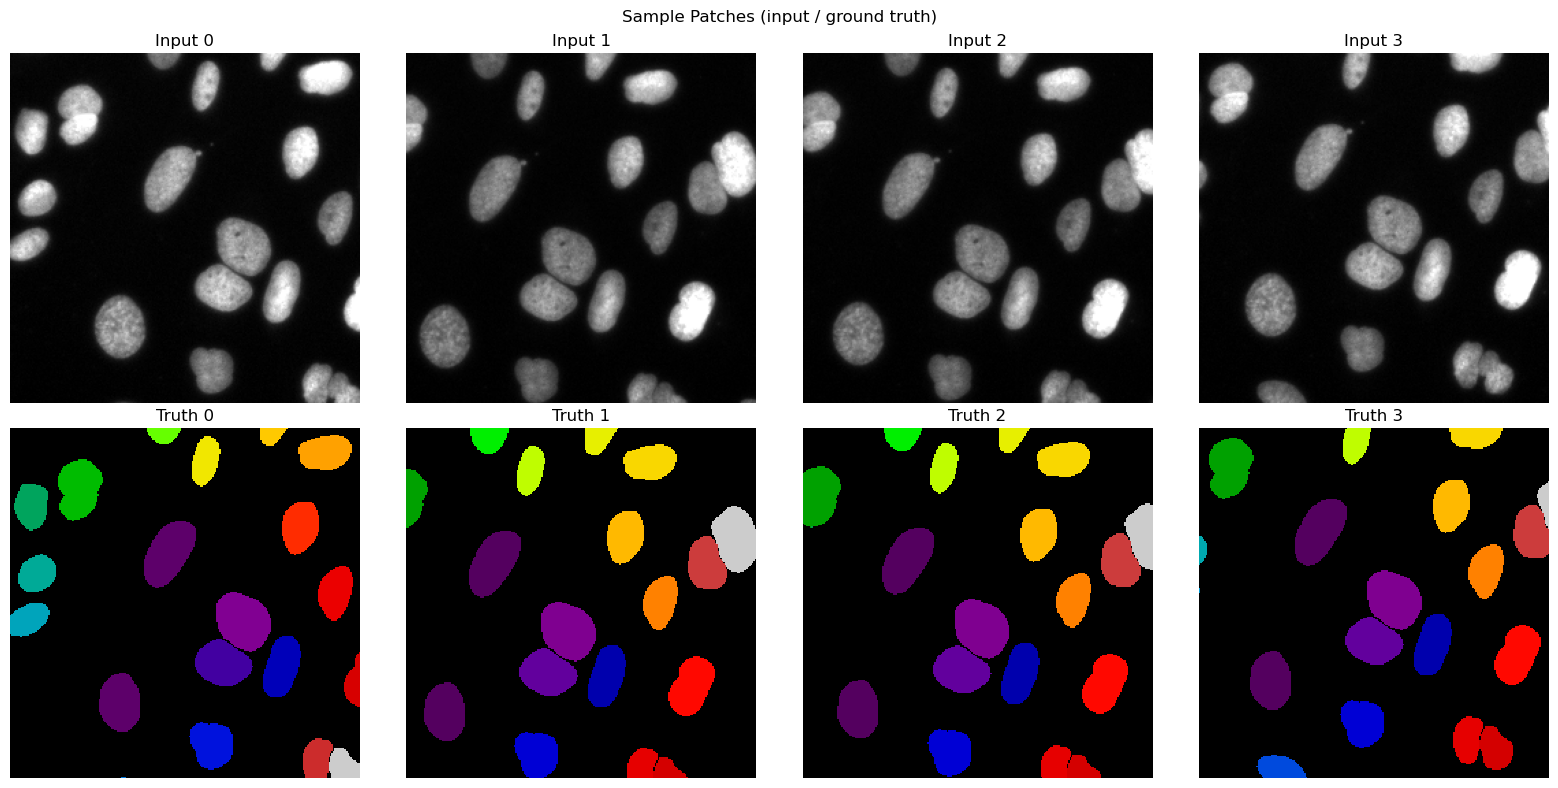

In [4]:
input_patches = sorted(Path(patches_dir, "input0").glob("*.tif"))
truth_patches = sorted(Path(patches_dir, "ground_truth0").glob("*.tif"))

n_show = min(4, len(input_patches))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for i in range(n_show):
    inp = tifffile.imread(str(input_patches[i]))
    gt = tifffile.imread(str(truth_patches[i]))

    axes[0, i].imshow(inp, cmap="gray")
    axes[0, i].set_title(f"Input {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gt, cmap="nipy_spectral", interpolation="nearest")
    axes[1, i].set_title(f"Truth {i}")
    axes[1, i].axis("off")

plt.suptitle("Sample Patches (input / ground truth)")
plt.tight_layout()
plt.show()

## 5. Train StarDist2D Model

Create a `StardistSegmenter`, set training hyper-parameters, and call `train()`.

In [ ]:
segmenter = StardistSegmenter()

# Training hyper-parameters (kept small for a quick test)
segmenter.num_epochs = 20
segmenter.steps_per_epoch = 50
segmenter.train_patch_size_y = 256
segmenter.train_patch_size_x = 256

# Set paths on segmenter (same as _run_training does in the GUI)
segmenter.patch_path = str(patches_dir)
segmenter.model_name = "stardist_nuclei_test"
segmenter.model_save_dir = str(project_path / "models")

model_name = segmenter.model_name
model_base_path = segmenter.model_save_dir

print(f"Patch path:  {segmenter.patch_path}")
print(f"Model name:  {model_name}")
print(f"Model base:  {model_base_path}")

Patch path:  /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/patches/patches_axis_yx
Model name:  stardist_nuclei_test
Model base:  /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/models


In [ ]:
# Run training (same signature as MonaiUNetSegmenter.train)
result = segmenter.train()
print(result)

0it [00:00, ?it/s]dl_util.py (111): The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
dl_util.py (112): The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
dl_util.py (111): The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
dl_util.py (112): The plugin infrastructure in `skimage.io` and the parameter `plu

🏋️ Training StarDist2D: 598 train, 2 val
   axes=YX, n_channel_in=1
   epochs=20, steps_per_epoch=50
   train_patch_size=(256, 256)


2026-04-01 19:23:32.969764: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 19:23:32.970548: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 19:23:32.975665: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Using default values: prob_thresh=0.5, nms_thresh=0.4.
Epoch 1/20


2026-04-01 19:23:35.788702: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2026-04-01 19:23:38.376538: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7201a2591e00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-01 19:23:38.376561: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-04-01 19:23:38.389646: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-01 19:23:38.476828: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-01 19:23:38.376538: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7201a2591e00 initialized for platform CUDA (this does not guarantee that

50/50 [==============================] - 13s 96ms/step - loss: 2.5559 - prob_loss: 0.4059 - dist_loss: 10.7501 - prob_kld: 0.3270 - dist_relevant_mae: 10.7497 - dist_relevant_mse: 176.3126 - dist_dist_iou_metric: 0.1314 - val_loss: 1.3658 - val_prob_loss: 0.1053 - val_dist_loss: 6.3029 - val_prob_kld: 0.0840 - val_dist_relevant_mae: 6.3018 - val_dist_relevant_mse: 69.8202 - val_dist_dist_iou_metric: 0.3256 - lr: 3.0000e-04
Epoch 2/20
50/50 [==============================] - 13s 96ms/step - loss: 2.5559 - prob_loss: 0.4059 - dist_loss: 10.7501 - prob_kld: 0.3270 - dist_relevant_mae: 10.7497 - dist_relevant_mse: 176.3126 - dist_dist_iou_metric: 0.1314 - val_loss: 1.3658 - val_prob_loss: 0.1053 - val_dist_loss: 6.3029 - val_prob_kld: 0.0840 - val_dist_relevant_mae: 6.3018 - val_dist_relevant_mse: 69.8202 - val_dist_dist_iou_metric: 0.3256 - lr: 3.0000e-04
Epoch 2/20
50/50 [==============================] - 3s 64ms/step - loss: 1.4737 - prob_loss: 0.2175 - dist_loss: 6.2809 - prob_kld: 0.1

## 6. Plot Training Loss

Read the CSV log written by StarDist/Keras and visualise the training curves.

In [7]:
import pandas as pd

log_csv = Path(model_base_path) / model_name / "logs" / "training.csv"

if log_csv.exists():
    df = pd.read_csv(log_csv)
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.plot(df["epoch"], df["loss"], label="train loss")
    if "val_loss" in df.columns:
        ax.plot(df["epoch"], df["val_loss"], label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("StarDist Training Loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"No training log found at {log_csv}")

No training log found at /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/models/stardist_nuclei_test/logs/training.csv


## 7. Predict on a Test Image

Load one of the nuclei images and run the trained model via `segmenter.segment()`.

In [8]:
# Load a test image from the project
test_images = sorted(project_path.glob("*.tif"))
test_image = tifffile.imread(str(test_images[0]))
print(f"Test image: {test_images[0].name}, shape={test_image.shape}, dtype={test_image.dtype}")

# The trained model is already on segmenter.custom_model after train()
predicted_labels = segmenter.segment(test_image)
print(f"Predicted labels: shape={predicted_labels.shape}, unique={len(np.unique(predicted_labels)) - 1} objects")

Test image: IXMtest_A02_s1_w1051DAA7C-7042-435F-99F0-1E847D9B42CB.tif, shape=(520, 696), dtype=uint16
Using custom StarDist model from: /home/bnorthan/code/i2k/tnia/napari-ai-lab/tests/test_images/nuclei/models/stardist_nuclei_test
🔍 StarDist input: shape=(520, 696), dtype=float32, ndim=2
🔍 TensorFlow GPU Check:
   TensorFlow version: 2.14.0
   GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Built with CUDA: True
   ✅ GPU ENABLED - using GPU acceleration
🔍 Calling model.predict_instances with shape=(520, 696), axes=None (will use model default)
StarDist: Found 74 objects (prob_thresh=0.5, nms_thresh=0.4)
Predicted labels: shape=(520, 696), unique=74 objects
StarDist: Found 74 objects (prob_thresh=0.5, nms_thresh=0.4)
Predicted labels: shape=(520, 696), unique=74 objects


## 8. Visualise Prediction

Side-by-side comparison of input, ground truth annotation (if available), and the StarDist prediction.

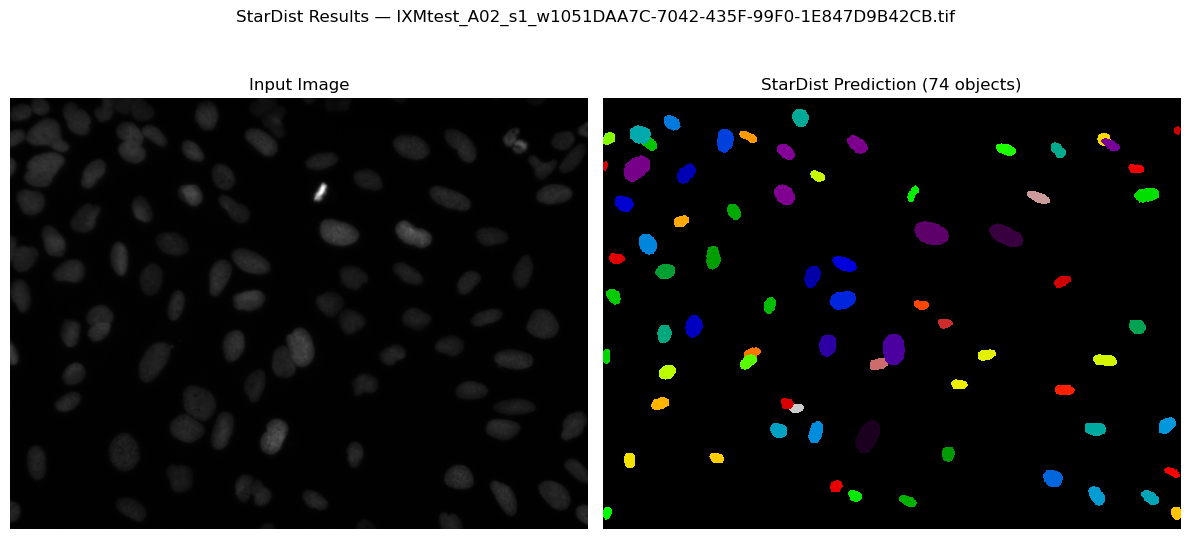

In [9]:
# Try to load an existing annotation for the same image
annotations_dir = project_path / "annotations"
annotation_name = test_images[0].stem + ".tif"
annotation_path = annotations_dir / annotation_name

has_gt = annotation_path.exists()

ncols = 3 if has_gt else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))

axes[0].imshow(test_image, cmap="gray")
axes[0].set_title("Input Image")
axes[0].axis("off")

if has_gt:
    gt = tifffile.imread(str(annotation_path))
    axes[1].imshow(gt, cmap="nipy_spectral", interpolation="nearest")
    axes[1].set_title(f"Ground Truth ({len(np.unique(gt)) - 1} objects)")
    axes[1].axis("off")
    pred_ax = axes[2]
else:
    pred_ax = axes[1]

pred_ax.imshow(predicted_labels, cmap="nipy_spectral", interpolation="nearest")
pred_ax.set_title(f"StarDist Prediction ({len(np.unique(predicted_labels)) - 1} objects)")
pred_ax.axis("off")

plt.suptitle(f"StarDist Results — {test_images[0].name}")
plt.tight_layout()
plt.show()

## 9. Overlay — Input with Prediction Contours

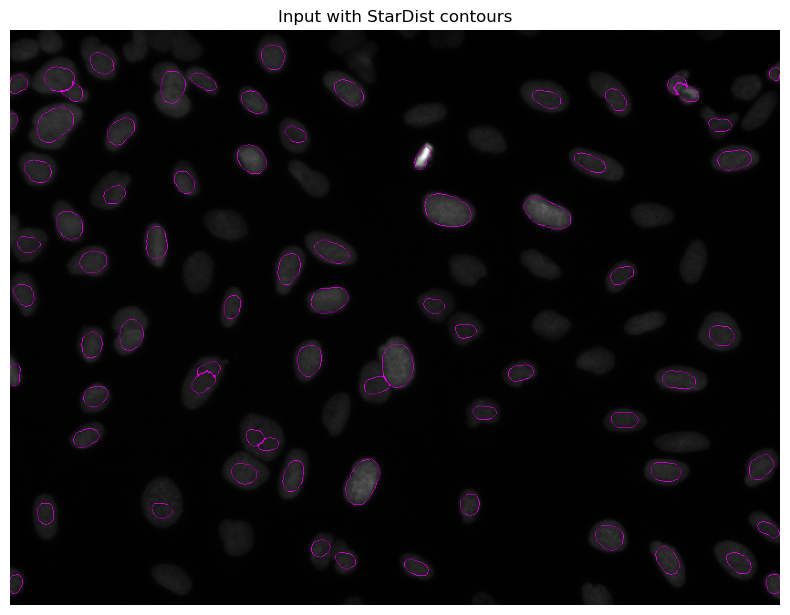

In [10]:
from skimage.segmentation import find_boundaries

boundaries = find_boundaries(predicted_labels, mode="outer")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(test_image, cmap="gray")
ax.imshow(np.ma.masked_where(~boundaries, boundaries), cmap="spring", alpha=0.8)
ax.set_title("Input with StarDist contours")
ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

| Step | What happened |
|------|---------------|
| **Setup** | Pointed to `tests/test_images/nuclei/` — labels already on disk |
| **Patches** | `generate_patches_from_labels` augmented 3 label crops × 200 = 600 patches |
| **Train** | `StardistSegmenter.train()` → Config2D + StarDist2D, 20 epochs |
| **Predict** | `segmenter.segment(image)` using the just-trained custom model |
| **Visualise** | Side-by-side comparison + boundary overlay |